Выполнил: __Голубев Артём Дмитриевич, P3123__

# Предсказание дефолта по кредиту

Многие люди берут кредит в банке. Некоторые не отдают. Если просрочка по кредиту больше 90 дней, банк считает, по данному кредиту произошел дефолт, то есть клиент не в состоянии его отдать.

Одна из первых задач, которую решало машинное обучение в банках, - предсказание дефолта.
Нужно по данным, которые предоставил потенциальный заемщик, определить, будет у него дефолт или нет.

Задача предсказания дефолта - задача классификации, а результат работы модели для конкретного клиента - предсказать произойдет дефолт или нет.
В этой тетради мы рассмотрим вопрос измерения качества работы обученных
классификаторов. На примерах мы опишем различные метрики качества и способы
их подсчёта. Также обратим внимание на адекватность их использования в типичных
практических кейсах.

<img src="https://drive.google.com/uc?id=1jQX02vTP_BKJIRPamIDRQ2U1Ub1NONNH" alt="Drawing" style="width: 50px;" width="360"/>

Мы попробуем на данных из Kaggle соревнования _"Give me some credit"_ обучить модель машинного обучения, которая будет предсказывать дефолт.
https://www.kaggle.com/c/GiveMeSomeCredit#description

**Бизнес-постановка задачи**

Банк по анкетным данным оценивает вероятность того, что для конкретного клиента произойдет дефолт.
Применение модели ясно:
* мы хотим выдавать кредиты только хорошим заемщикам, которые отдадут кредит.

**Постановка задачи анализа данных**

Целью данной задачи является построение модели *классификации дефолтов*: на вход модель будет принимать данные о клиенте, а на выходе она должна работать в двух режимах:
* выдавать вероятность дефолта для данного клиента,
* выдавать правильный с точки зрения модели класс клиента (есть у него дефолт или нет).

Обучать модель мы будем по данным с платформы kaggle.

**Обзор доступных данных**

В выборке N наблюдений и 11 переменных, одна из которых - целевая.
Таким образом, про каждого из N клиентов мы знаем значения 11 их характеристик (возраст, доход в месяц), в том числе значение целевой переменной: есть ли у клиента сейчас просрочка более 90 дней.

Выборка была разбита на две части для обучения и для тестирования модели.

**Доступные признаки**

Данные содержат два типа переменных:

* Целевая: **SeriousDlqin2yrs**, есть ли просрочка 90 дней и более
* Остальные переменные: 10 переменных, могут использоваться для прогноза целевой переменной.

| Имя столбца        | Значение |
| :-------------: |:-------------:|
| SeriousDlqin2yrs      | **Целевая переменная:** Есть ли просрочка 90 дней и более |
| RevolvingUtilizationOfUnsecuredLines      | Доля использованных лимитов по кредитным картам     |
| age | Возраст заемщика в годах |
| DebtRatio | Отношение суммы долговой нагрузки, расходов на жизнь и алименты к доходу |
| MonthlyIncome | Доход в месяц |
| NumberOfOpenCreditLinesAndLoans | Количество открытых кредитов и кредитных линий (кредитных карт) |
| NumberRealEstateLoansOrLines | Количество ипотек и других кредитных продуктов, связанных с недвижимостью |
| NumberOfTime30-59DaysPastDueNotWorse | Сколько раз за последние 2 года у заемщика была просрочка 30-59 дней |
| NumberOfTime60-89DaysPastDueNotWorse | Сколько раз за последние 2 года у заемщика была просрочка 60-89 дней |
| NumberOfTimes90DaysLate | Сколько раз за последние 2 года у заемщика была просрочка более 90 дней |
| NumberOfDependents | Количество иждивенцев в семье (супруг, дети и т.п.) |



## План анализа данных (data mining):

  1. Загрузить данные для обучения
  2. Обработать данные перед обучением модели
  3. Обучить модель на обучающей выборке
  4. Загрузить и предобработать данные для тестирования
  5. Провалидировать модель на тестовой выборке

## 1. Загрузить данные для обучения

**Шаг 1.1. Загружаем библиотеки**

Для корректной работы с данными в python требуется загрузить специальную библиотеку
**pandas**, программную библиотеку на языке python для обработки и анализа данных.

Основная нагрузка по обработке входных данных ложится на модуль **pandas**. С
помощью функций `pandas.read_*` можно подтягивать данные из простых текстовых
файлов `CSV`, таблиц **Excel**, таблиц **HTML**, а также **SQL** запросами
из корпоративных баз данных и прочих распределённых хранилищ.

In [ ]:
import pandas as pd

Для корректной работы с графиками в python требуется загрузить специальную библиотеку
**matplotlib**, программную библиотеку на языке python для визуализации данных двумерной и трехмерной графикой.

Графики используются для облегчения интерпретации полученных результатов, а также в качестве иллюстраций в презентациях и отчетах.

Оснвные методы для построения:
* plot() - графики
* semilogy() - график логарифметический
* hist() - гистограммы

In [ ]:
import matplotlib.pyplot as plt # загружаем библиотеку и для простоты обращения в коде называем её сокращенно plt

Основную вычислительную нагрузку берёт на себя модуль **Numpy**, с помощью которого можно быстро производить
вычисления сразу над массивами чисел.

In [ ]:
import numpy as np

Библиотека **scikit-learn** -- де факто наиболее популярный, разносторонний, хорошо
документированный и постоянно обогащающийся инструмент для построения моделей машинного
обучения.

Выберем из него:
* классификатор дерево решений (**DecisionTreeClassifier**);
* метод для удобной $k$*-fold* кросс-валидации (**KFold**);
* несколько готовых функции для расчёта метрик качества классификации.

In [ ]:
from sklearn.tree import DecisionTreeClassifier # классификатор дерева решений

from sklearn.model_selection import KFold # k-fold кросс-валидация

from sklearn.metrics import roc_curve, precision_recall_curve, auc # метрики качества
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score # метрики качества
from sklearn.metrics import average_precision_score # метрики качества

Помимо задачи загрузки, расчётов и обучения моделей, немаловажную роль играет визуализация.
Она полезна как для предварительного анализа, так и для исследования метрик качеста, а также
упрощяет принятие решений и обобщение результатов.

Мы будем использовать библиотеку **MatplotLib**, которая отлично справляется с этой задачей.
Модуль **seaborn** устанавливет "приятные для глаз" палитры и стили для графиков.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style('whitegrid') # установить стиль whitegrid, другие стили можно найти в документации к seaborn

Некоторые библиотеки могут выводить на экран предупреждения, которые важно учитывать в "боевых" задачах. Но в учебной тетради мы укажем Python'у игнорировать их.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

<br/>

**Шаг 1.2. Загрузим данные**

Для решения задачи мы будем использовать данные. Они состоят из двух частей: часть для обучения и часть для тестирования модели. Загружаем данные с помощие команды !wget. Для того, чтобы игнорировать сообщения в процессе загрузки используем магическую команду %%capture в первой строке.

In [ ]:
%%capture
!wget https://www.dropbox.com/s/io67uppgq66plbp/training_data.csv
!wget https://www.dropbox.com/s/2ga9maqxbsf8xhg/test_data.csv


Наши данные в формате `csv` - comma separated values, значения, разделенные точкой. Обычно data scientists работают с табличными данными, которые представлены именно в таком виде. Чтобы загрузить такие данные, будем использовать функцию **`pd.read_csv()`** из библиотеки `pandas`.

In [ ]:
training_data = pd.read_csv('training_data.csv')


Посмотрим на 10 случайно выбранных записей из обучающего набора, для этого будем использовать функцию **sample()**. Параметр
**random_state=123** фиксирует "случайность", то есть на любом компьютере метод **sample()** будет работать одинаково.

In [ ]:
# training_data.head(10)

training_data.sample(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
12150,0,0.072754,53,0,0.653631,8054.0,8,0,2,0,0.0
14097,0,0.009520,46,0,0.001137,6158.0,3,0,0,0,1.0
23537,0,0.025947,40,0,1487.000000,NaN,9,0,1,0,0.0
511,1,0.601297,47,0,0.312320,6233.0,8,0,1,0,2.0
8519,1,0.380228,41,0,0.570040,3704.0,9,0,0,0,0.0
46290,0,0.661482,58,0,0.660600,3900.0,9,0,2,0,1.0
2873,0,0.233077,78,1,0.388261,5400.0,10,0,1,0,4.0
6683,0,1.000000,41,0,0.277817,7000.0,7,0,2,0,0.0
11518,0,0.141403,38,0,0.676477,4960.0,3,0,1,0,1.0
10950,0,0.003733,83,0,0.000000,NaN,3,0,0,0,0.0


**Шаг 1.3. Посмотрим общую статистику по данным**

Посмотрим на технические параметры загруженных данных для обучения. Для этого вызовем метод `describe()` для набора данных `training_data`

Для удобства отображения мы транспонируем результат: меняем местами столбцы и строки.

In [ ]:
training_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,50000.0,0.066860,0.249782,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,50000.0,7.927880,332.393142,0.0,0.030096,0.154426,0.555651,50708.0
age,50000.0,52.240520,14.766593,21.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,50000.0,0.428220,4.269296,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,50000.0,352.441921,2006.426016,0.0,0.176304,0.366811,0.862599,329664.0
MonthlyIncome,40147.0,6642.232222,18122.708690,0.0,3400.000000,5400.000000,8250.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,50000.0,8.476040,5.172756,0.0,5.000000,8.000000,11.000000,57.0
NumberOfTimes90DaysLate,50000.0,0.269920,4.243110,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,50000.0,1.017500,1.120151,0.0,0.000000,1.000000,2.000000,32.0
NumberOfTime60-89DaysPastDueNotWorse,50000.0,0.246040,4.231055,0.0,0.000000,0.000000,0.000000,98.0


Обратим внимание на общие статистики показателей в данных:
* **count** -- количество значений, которые не являются пропущенными (`NaN`);
* **mean**, **std** -- среднее и разброс данных в соответствующем поле;
* остальные статистики -- минимальное и максимальное значения, и квантили.

Из таких характеристик столбцов мы уже можем извлечь некоторую информацию о данных:
* У столбца **SeriousDlqin2yrs** среднее 0.060. Значит, в нашей выборке только у 6% клиентов есть дефолт.
* У столбца **MonthlyIncome** заполнено только 40147 из 50000. Минимальное значение дохода - 0, максимальное - 3008750.
* У столбца **NumberOfDependents** большое количество значений - нулевые.

## 2. Обработать данные перед обучением модели

**Шаг 2.1. Проверяем данные на наличие пропусков и типов переменных**

Начнем с проверки общей информации о данных.
Для того чтобы это сделать, нужно обратиться вызвать у переменной *training_data* метод **info()**.

Напомним, что info — метод, а значит необходимо поставить скобки.

In [ ]:
# 1. TODO

In [ ]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      50000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  50000 non-null  float64
 2   age                                   50000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  50000 non-null  int64  
 4   DebtRatio                             50000 non-null  float64
 5   MonthlyIncome                         40147 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       50000 non-null  int64  
 7   NumberOfTimes90DaysLate               50000 non-null  int64  
 8   NumberRealEstateLoansOrLines          50000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  50000 non-null  int64  
 10  NumberOfDependents                    48667 non-null  float64
dtypes: float64(4), 

Метод `info()` выводит информацию о таблице типа `pd.DataFrame`, включая формат `dtype` и `dtypes` столбца, ненулевые значения и использование памяти.

**Шаг 2.2. Заполнение пропусков**

Рассчитаем средние значения признаков в обучающей выборке, и заполним полученными
числами пропуски как в **тестовом наборе** данных, так и в **самой обучающей выборке**.

Мы будем заполнять средними значениями из обучающей выборки, так как при решении реальной задачи нам будут доступны только данные для обучения.

Для получения средних значений вызовем метод `mean()`. По умолчанию метод считает средним значения по столбцам. После выполнения ячейки средние значения записаны в переменной `train_mean`



In [ ]:
# 2. TODO
train_mean = training_data.mean()
train_mean

,0
SeriousDlqin2yrs,0.066860
RevolvingUtilizationOfUnsecuredLines,7.927880
age,52.240520
NumberOfTime30-59DaysPastDueNotWorse,0.428220
DebtRatio,352.441921
MonthlyIncome,6642.232222
NumberOfOpenCreditLinesAndLoans,8.476040
NumberOfTimes90DaysLate,0.269920
NumberRealEstateLoansOrLines,1.017500
NumberOfTime60-89DaysPastDueNotWorse,0.246040


Пропуски в данных можно заполнять и разными методами:
* выборочной статистикой (среднее, медиана);
* прогнозами регрессии по известыми признакам;
* случайными значениями.

Если относительно небольшая доля наблюдению имеет пропуски, то можно
вовсе исключить неполные наблюдения с пропущенными значениями из выборки.

Для заполнения средним значеним, передадим на вход методу `fillna` полученный ранее набор средних значений для каждого столбца. Опция `inplace=True` говорит, что мы запишем изменения прямо в существующий массив, а не создадим новый.

In [ ]:
# 3. TODO
training_data.fillna(train_mean, inplace=True)
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      50000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  50000 non-null  float64
 2   age                                   50000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  50000 non-null  int64  
 4   DebtRatio                             50000 non-null  float64
 5   MonthlyIncome                         50000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       50000 non-null  int64  
 7   NumberOfTimes90DaysLate               50000 non-null  int64  
 8   NumberRealEstateLoansOrLines          50000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  50000 non-null  int64  
 10  NumberOfDependents                    50000 non-null  float64
dtypes: float64(4), 

**Шаг 2.3. Работаем с целевой переменной**

*Какая переменная целевая?*

В данном случае по условию задачи мы должны прогнозировать дефолт, поэтому целевая переменная - это наличие дефолта.

In [ ]:
target_variable_name = 'SeriousDlqin2yrs'

Обратим внимание на целевой признак **SeriousDlqin2yrs** -- наличие серьёзной просрочки
по кредитным выплатам за последние два года. Обычно заёмщики стараются производить выплаты
вовремя.

Чтобы посчитать количество хороших заемщиков без больших просрочек (значение переменной **SeriousDlqin2yrs** равно нулю) и плохих с просрочкой (значение **SeriousDlqin2yrs** равно единице) вызовем метод `value_counts()`

In [ ]:
training_data[target_variable_name].value_counts()

,count
SeriousDlqin2yrs,
0,46657
1,3343


Нам нужно выделить в отдельную переменную *training_values* столбец из нашей таблицы, который соответствует определенной выше целевой переменной. Для этого мы у таблицы *training_data* в квадратных скобках указываем имя нужного столбца. В нашем случае это имя записано в переменной *target_variable_name*.

In [ ]:
# 4. TODO
training_values = training_data[target_variable_name]

Проверим размерность целевой переменной

In [ ]:
training_values.shape

(50000,)

Запись `(50000,)` равносильна `(50000, 1)`.  Она означает, что у нас 50000 экземпляров в выборке и 1 признак

Отделим входные переменные от выходной (целевой), чтобы можно было построить модель предсказания целевой переменной по входным. Для это нужно у переменной training_data вызвать метод drop().

In [ ]:
# 5. TODO
training_points = training_data.drop(target_variable_name, axis=1)
training_points.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RevolvingUtilizationOfUnsecuredLines  50000 non-null  float64
 1   age                                   50000 non-null  int64  
 2   NumberOfTime30-59DaysPastDueNotWorse  50000 non-null  int64  
 3   DebtRatio                             50000 non-null  float64
 4   MonthlyIncome                         50000 non-null  float64
 5   NumberOfOpenCreditLinesAndLoans       50000 non-null  int64  
 6   NumberOfTimes90DaysLate               50000 non-null  int64  
 7   NumberRealEstateLoansOrLines          50000 non-null  int64  
 8   NumberOfTime60-89DaysPastDueNotWorse  50000 non-null  int64  
 9   NumberOfDependents                    50000 non-null  float64
dtypes: float64(4), int64(6)
memory usage: 3.8 MB


In [ ]:
training_data.shape # (50000, 11)

(50000, 11)

In [ ]:
training_points.shape # (50000, 10)

(50000, 10)

Видно, что столбца действительно нет, а количество строк не изменилось.

##   3. Обучить модель на обучающей выборке

**Шаг 3.1. Выбираем метод, который будем использовать**

Проще всего начать с простых методов.
Мы воспользуемся двумя методами для построения моделей классификации и сравним их между собой:
* Логистическая регрессия *logistic regression*
* Лес решающих деревьев *random forest*

Логистическая регрессия - "адаптация" линейной регрессии для решения задачи классификации. Она принадлежит к классу обобщенных линейных моделей.
А вот с помощью леса решающих деревьев можно хорошо решать и задачу регрессии, и задачу классификации.

Для корректной работы с методами построения моделей в python требуется загрузить специальную библиотеку
**sklearn**, программную библиотеку на языке python для для машинного обучения и анализа данных.

Мы импортируем два модуля из этой библиотеки:
 * *linear_model* - тут находятся все линейные *и обобщенные линейные* модели, в том числе модель логистической регрессии.
 * *ensemble* - тут находятся модели на основе ансамблей.

In [ ]:
from sklearn import linear_model, ensemble


Чтобы создать модель логистической регресии, пишем имя модуля 'linear_model', затем точку, затем название модели.

Для этого нужно выполнить следующий код:

```python
log_reg_model = linear_model.LogisticRegression()
log_reg_model
```

In [ ]:
# 6. TODO
log_reg_model = linear_model.LogisticRegression()
log_reg_model

LogisticRegression()

Результат выполнения должен быть следующим:

```python
LogisticRegression(C=1.0, class_weight=None, dual=False,
          fit_intercept=True, intercept_scaling=1,
          max_iter=100, multi_class='warn', n_jobs=None,
          penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)
```

Модель логистической регрессии сложнее, чем модель линейной регрессии. Поэтому параметров у такой модели гораздо больше. Многие из них связаны с тем, с помощью какой процедуры мы будем подбирать параметры модели (*max_iter*, *dual*, *solver*, *tol*, *warm_start*), устойчивостью модели (*C*, *penalty*), тем, что мы решаем задачу классификации, а не регрессии (*class_weight*, *multi_class*)

Чтобы создать модель случайного леса, пишем имя модуля ensemble, затем точку, затем название модели.

Для этого нужно выполнить следующий код:

```python
random_forest_model = ensemble.RandomForestClassifier()
random_forest_model
```

Код отличается от кода при решении задачи регрессии тем, что теперь нам нужна модель для классификации `RandomForestClassifier`, а не регрессии `RandomForestRegressor`.
Результат выполнения должен быть следующим:
    
```python
RandomForestClassifier(bootstrap=True, class_weight=None,
            criterion='gini', max_depth=None, max_features='auto',
            max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn',
            n_jobs=None, oob_score=False, random_state=None,
            verbose=0, warm_start=False)
```

Создадим модель в переменной ```random_forest_model``` с параметром ```n_estimators=100```.

In [ ]:
# 7. TODO
random_forest_model = ensemble.RandomForestClassifier(n_estimators=100)

In [ ]:
random_forest_model

RandomForestClassifier()

У модели классификации на основе случайного леса больше параметров. Рассмотрим наиболее важные:
* параметр *n_estimators* определяет, сколько деревьев в лесу,
* в параметре *max_depth* устанавливается, какая максимальная глубина у дерева,
* в параметре *min_samples_leaf* задается, какое максимальное число объектов может попасть в лист дерева.

**Шаг 3.2. Обучить модель**

Теперь, когда мы создали прототипы обеих моделей, можем их обучить с помощью обучающей выборки.

Для этого вызываем метод **fit()** у каждой модели и передаем ему на вход два аргумента:
таблицу входных признаков и столбец значений целевой переменной - (training_points, training_values)

In [ ]:
# 8. TODO
log_reg_model.fit(training_points, training_values)

LogisticRegression()

Делаем тоже самое для модели решающего леса.

Возможно, будут предупреждения, о том, что планируются изменения в будущем в этой модели (FutureWarning).

In [ ]:
# 9. TODO
random_forest_model.fit(training_points, training_values)

RandomForestClassifier()

* Для двух разных моделей в sklearn методы для обучения модели не отличаются.
* Мы получили две обученные модели.
* Теперь необходимо провалидировать модели на новых тестовых данных, которые не использовались при обучении модели.

## 4. Загрузить и предобработать данные для тестирования

**Шаг 4.1. Загрузим данные для тестирования**

Наши данные в формате `csv` - comma separated values, значения, разделенные точкой. Обычно data scientists работают с табличными данными, которые представлены именно в таком виде. Чтобы загрузить такие данные, будем использовать функцию `pd.read_csv` из библиотеки `pandas`.

In [ ]:
test_data = pd.read_csv('test_data.csv')

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37500 entries, 0 to 37499
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      37500 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  37500 non-null  float64
 2   age                                   37500 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  37500 non-null  int64  
 4   DebtRatio                             37500 non-null  float64
 5   MonthlyIncome                         30044 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       37500 non-null  int64  
 7   NumberOfTimes90DaysLate               37500 non-null  int64  
 8   NumberRealEstateLoansOrLines          37500 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  37500 non-null  int64  
 10  NumberOfDependents                    36521 non-null  float64
dtypes: float64(4), 

In [ ]:
test_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,37500.0,0.067387,0.250694,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,37500.0,6.031470,201.538421,0.0,0.029634,0.155112,0.565469,18300.0
age,37500.0,52.367387,14.769995,0.0,41.000000,52.000000,63.000000,107.0
NumberOfTime30-59DaysPastDueNotWorse,37500.0,0.448613,4.478678,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,37500.0,341.402289,1131.165077,0.0,0.173310,0.365951,0.866864,60212.0
MonthlyIncome,30044.0,6571.071295,7639.608316,0.0,3383.000000,5374.500000,8200.000000,562466.0
NumberOfOpenCreditLinesAndLoans,37500.0,8.428587,5.143302,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,37500.0,0.292667,4.458953,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,37500.0,1.020160,1.152043,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,37500.0,0.266160,4.444065,0.0,0.000000,0.000000,0.000000,98.0


**Шаг 4.2. Предобработка данных для тестирования**

Тестовые данные нужно предобработать аналогично обучающим. Поэтому заполним сперва пропуски в данных.

Для заполнения средним значеним, передадим на вход методу `fillna` полученный ранее набор средних значений для каждого столбца. Опция `inplace=True` говорит, что мы запишем изменения прямо в существующий массив, а не создадим новый

In [ ]:
# 10. TODO
test_mean = test_data.mean()
test_data.fillna(test_mean, inplace=True)
test_data

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.166035,25,0,687.000000,6571.071295,9,0,0,0,0.0
1,1,1.036867,42,3,0.664400,5440.000000,12,0,2,0,3.0
2,0,0.100229,62,2,1.263068,3500.000000,11,0,2,0,0.0
3,0,0.232698,37,0,0.088482,3333.000000,5,0,0,0,0.0
4,1,0.950586,41,2,0.321115,11266.000000,6,1,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
37495,0,0.065113,45,0,1424.000000,6571.071295,12,0,1,0,0.0
37496,0,0.231449,50,0,0.439138,15074.000000,15,0,3,0,1.0
37497,0,0.908877,64,0,0.330960,2667.000000,5,0,0,0,0.0
37498,0,0.139054,64,0,2256.000000,6571.071295,13,0,1,0,0.0


In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37500 entries, 0 to 37499
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      37500 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  37500 non-null  float64
 2   age                                   37500 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  37500 non-null  int64  
 4   DebtRatio                             37500 non-null  float64
 5   MonthlyIncome                         37500 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       37500 non-null  int64  
 7   NumberOfTimes90DaysLate               37500 non-null  int64  
 8   NumberRealEstateLoansOrLines          37500 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  37500 non-null  int64  
 10  NumberOfDependents                    37500 non-null  float64
dtypes: float64(4), 

**Шаг 4.3. Отделяем целевую переменную**

Нам нужно выделить в отдельную переменную *test_values* столбец из нашей таблицы, который соответствует определенной выше целевой переменной. Для этого мы у таблицы *test_data* в квадратных скобках указываем имя нужного столбца. В нашем случае это имя записано в переменной *target_variable_name*.

In [ ]:
# 11. TODO
test_values = test_data[target_variable_name]

In [ ]:
# 12. TODO
test_points = test_data.drop(target_variable_name, axis=1)

И проверяем результат записанный в test_points

In [ ]:
test_points.shape # (37500, 10)

(37500, 10)

## 5. Провалидировать модель на тестовой выборке

<img src="https://drive.google.com/uc?id=1QbHrix_UrbD77BmIGiitiaH8nB8UdUmj" alt="Drawing" style="width: 400px;"/>



Сначала получим прогноз модели на тестовых данных *`test_points`* с помощью моделей логистической регрессии и решающего леса.
Для этого для обеих моделей запустим метод **`predict()`**.

In [ ]:
# 13. TODO
test_predictions_logistic_regression = log_reg_model.predict(test_points)

In [ ]:
# 14. TODO
test_predictions_random_forest = random_forest_model.predict(test_points)

Посмотрим, сколько предсказаний каждого вида (дефолтов и возвратов кредитов) спрогнозировали модели. Для этого необходимо вызвать функцию **`value_counts()`** из библиотеки **`pandas`** для полученных прогнозов.

In [ ]:
# 15. TODO
pd.value_counts(test_predictions_logistic_regression)

,count
0,37436
1,64


Модель логистической регрессии предсказывает X неуплат и Y возвратов кредита в срок.  

In [ ]:
# 16. TODO
pd.value_counts(test_predictions_random_forest)

,count
0,36633
1,867


Модель случайного леса предсказывает X' случаев неуплаты и Y' возврата кредита в срок.  

### Шаг 5.1. Точность прогноза

Естественный способ измерить качество модели - посчитать долю правильных предсказаний, то есть, сколько в процентном соотношении от размера тестовой выборки модель угадала единичек и сколько угадала ноликов. Такая метрика называется точность (accuracy).

<img src="https://drive.google.com/uc?id=1ITTp5pCtDKszhkkLXzXiuCWi09VJaioA" alt="Drawing" style="width: 600px;"/>

Функция для подсчета точности реализована в библиотеке **sklearn** и называется **`accuracy_score()`**. Импортируем её.

In [ ]:
from sklearn.metrics import accuracy_score

В функцию **`accuracy_score()`** необходимо передать два аргумента:
* истинные значения меток - *test_values*
* предсказания модели - *test_predictions_logistic_regression* или *test_predictions_random_forest*

In [ ]:
# 17. TODO
accuracy_score(test_values, test_predictions_logistic_regression)

0.9324533333333334

In [ ]:
accuracy_score(test_values, test_predictions_random_forest)

0.9342933333333333

**Как понять, хорошо работает модель или нет?**

Из значения точности мы никак не можем понять, сколько меток каждого класса правильно предсказала модель. В нашей задаче мало значений с классом 1 (дефолт), но много 0 (возврат кредита). Может быть такая ситуация, когда модель очень хорошо научилась выделять характеристики большого класса, в нашем случае 0, но совсем не умеет выделять характеристики маленького класса. А часто именно последние в большей степени интересуют аналитиков.

Самый простой способ проверить - это сравнить значения точности для наших моделей с точностью для константного классификатора, модели, которая всегда бы предсказывала больший класс, в нашем случае 0.
Для этого можно в функцию **`accuracy_score()`** в качестве второго аргумента передать массив нулей такого же размера, как и *test_values*. Это делается с помощью функции **`zeros_like()`** из библиотеки numpy, у которой один аргумент - *test_values*, массив с размером которого будет создан массив нулей.

In [ ]:
# 18. TODO
accuracy_score(test_values, np.zeros_like(test_values))

0.9326133333333333

Действительно, для логистической регрессии точность очень близка к точности константного классификатора. Это не означает, что логистическая регрессия работает определенно плохо, но необходимо проверить дополнительные метрики.

### Шаг 5.2. Таблица сопряженности модели классификации

Другой способ оценивать качество работы классификатора - использовать таблицу сопряженности.

**Таблица сопряжённости** (матрица неточности, или Confusion matrix) содержит сводные показатели качества работы классификатора. **Строки** этой таблицы соответствуют **фактическим классам** тестового набора, а **столбцы** - **предсказанным** классификатором меткам.

Импортируем функцию для построения таблицы сопряженности из библиотеки **`sklearn`**.

In [ ]:
from sklearn.metrics import confusion_matrix

Таблица содержит четыре сводных показателя, каждый из которых отражает количество объектов в одной и четырех
категорий:
* **истинно позитивный** (*True positive*, **TP**) -- объект
класса `1` был верно помечен меткой `1`;
* **ложно позитивный** (*False positive*, **FP**) -- объект
фактически принадлежит классу `0`, но помечен меткой `1`;
* **истинно отрицательный** (*True negative*, **TN**) -- классификатор
верно определил, что объект класса `0` принадлежит классу `0`;
* **ложно отрицательный** (*False negative*, **FN**) -- классификатор
пометил объект меткой `0`, однако на самом деле объект принадлежит классу `1`.


Замечание: ошибки False positive часто называют **ложной тревогой**, а False negative - **пропуском цели**.

|                   |  Предсказано `0` |  Предсказано `1` |
|:-------------------|:------------------|:------------------|
|**Фактически** `0`  |       TN         |       FP         |
|**Фактически** `1`  |       FN         |       TP         |

Посмотрим на таблицу сопряженности для логистической регрессии и случайного леса. Для этого в функцию **`confusion_matrix()`** необходимо передать два аргумента:
* истинные значения меток - *test_values*
* предсказания модели - *test_predictions_random_forest* и аналогично для второй модели — *test_predictions_logistic_regression*

Далее для удобства мы запишем полученную матрицу в удобный табличный вид, воспользовавшись функцией **`DataFrame()`** из библиотеки **pandas**.

In [ ]:
# 19. TODO

logistic_regression_confusion_matrix = confusion_matrix(test_values, test_predictions_logistic_regression)
logistic_regression_confusion_matrix = pd.DataFrame(logistic_regression_confusion_matrix)

logistic_regression_confusion_matrix

,0,1
0,34938,35
1,2498,29


In [ ]:
# 20. TODO

random_forest_confusion_matrix = confusion_matrix(test_values, test_predictions_random_forest)
random_forest_confusion_matrix = pd.DataFrame(random_forest_confusion_matrix)

random_forest_confusion_matrix

,0,1
0,34571,402
1,2062,465


Разберем полученные значения подробнее:

<img src="https://drive.google.com/uc?id=1xBlpY2UwXy94IYxAme4OXZxxaNm57A3x" alt="Drawing" style="width: 400px;" width="700"/>


Почему значения на картинке могут отличаются от тех, которые мы получили?

`random_seed` не был зафиксирован в модели Случайных лесов, и мы видим незначительные отклонения в результатах предсказания.

### Шаг 5.3. Прогноз вероятности принадлежности к классу

Вместо прогноза меток классов модель может с помощью метода **`predict_proba()`** выдавать метки вероятности принадлежности к классам.
Так как класса у нас 2: заемщики с дефолтом и без, то матрица будет размером **1x2**.

In [ ]:
test_probabilities = log_reg_model.predict_proba(test_points)

Посмотрим на первые пять значений этой матрицу:

In [ ]:
test_probabilities[:5, :]

array([[0.82039729, 0.17960271],
       [0.8365228 , 0.1634772 ],
       [0.9472444 , 0.0527556 ],
       [0.88775646, 0.11224354],
       [0.92404023, 0.07595977]])

Вероятность принадлежности ко второму классу - во втором столбце матрицы вероятностей.

In [ ]:
test_probabilities = test_probabilities[:, 1]

Посмотрим на распределение предсказанной классификатором вероятности дефолта, метки `1`.

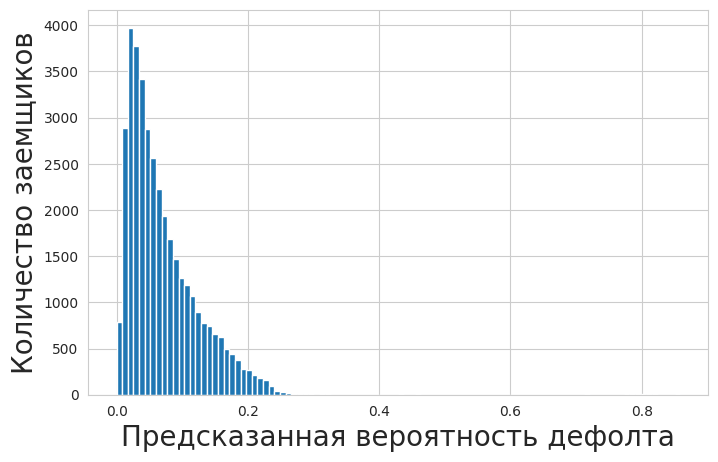

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(test_probabilities, bins=100)

plt.xlabel('Предсказанная вероятность дефолта', fontsize=20)
plt.ylabel('Количество заемщиков', fontsize=20);

Распределение сконцентрировано на отрезке от `0` до `0.3` и лишь незначительная часть вероятностей превышает порог `0.5`. Из
этого можно предположить, что классификатор склонен классифицировать все
объекты скорее как `0`, игнорируя метку `1`. Это происходит потому, что меток `1` в обучающей выборке сильно меньше, чем меток `0`.

### Шаг 5.4. Выбор порога классификатора

На самом деле, при вызове метода **`predict()`** классификатор преобразует полученные вероятности в метки. По умолчанию для этого используется сравнение с порогом $0.5$: если вероятность объекта меньше порога, то этот объект относится к классу 0, если больше - к классу 1.  

По умолчанию классификатор использует порог $0.5$, чтобы из вероятностей принадлежности к классу сделать метки классов.  

**За что отвечает порог классификатора?**

Порог классификатора контролирует соотношение между количеством False positive и False negative. Если мы задаем слишком высокий порог классификатора, то он редко предсказывает 1, но часто 0, таким образом, увеличивается количество False negative и уменьшается количество False positive. Если же порог низкий - мы часто предсказываем 1, а 0 реже, значит увеличивается количество False positive и уменьшается False negative.

Что это значит в нашей задаче кредитного скоринга? Если порог высокий, то мы реже считаем клиентов подозрительными и чаще выдаем клиентам кредит. В этом случае банк может потерять много денег из-за невозвратов. Если же порог низкий, то мы чаще считаем клиентов подозрительными и выдаем мало кредитов. Очевидно, это тоже плохо, так как мы часто не выдаем кредиты честным клиентам, что отражается на прибыли банка.

Посмотрим на то, как влияет порог на матрицу сопряженности.  

In [ ]:
higher_thershold = 0.7
alternative_test_predictions = test_probabilities > higher_thershold


In [ ]:
alternative_confusion_matrix = pd.DataFrame(confusion_matrix(test_values, alternative_test_predictions))
alternative_confusion_matrix

,0,1
0,34947,26
1,2508,19


Действительно, количество ложно-отрицательных (False negative) срабатываний увеличилось, а количество ложно-положительных срабатываний (False positive) уменьшилось.

**Задание:** получите confusion matrix для уменьшенного значения порога 0.3

In [ ]:
# 21. TODO
lower_thershold = 0.3
alternative_test_predictions = test_probabilities > lower_thershold

alternative_confusion_matrix = pd.DataFrame(confusion_matrix(test_values, alternative_test_predictions))
alternative_confusion_matrix

,0,1
0,34925,48
1,2483,44


In [ ]:
# 22. TODO
# Получите confusion matrix для порогов: 0.3, 0.5, 0.7 для алгоритма Random Forest и выведите её.

random_forest_confusion_matrix

,0,1
0,34571,402
1,2062,465


In [ ]:
test_forest_proba = random_forest_model.predict_proba(test_points)[:, 1]

alt_forest_prediction_higher = test_forest_proba > higher_thershold
alt_forest_prediction_lower = test_forest_proba > lower_thershold

In [ ]:
alt_conf_matrix_forest_high = pd.DataFrame(confusion_matrix(test_values, alt_forest_prediction_higher))
alt_conf_matrix_forest_high

,0,1
0,34906,67
1,2409,118


In [ ]:
alt_conf_matrix_forest_low = pd.DataFrame(confusion_matrix(test_values, alt_forest_prediction_lower))
alt_conf_matrix_forest_low

,0,1
0,33553,1420
1,1537,990


### *Бонус:  ROC кривая классификатора

Если хотят сравнить метрики на разных наборах данных, обычно работают не с абсолютными значениями True Positive и False Positive, а с их долями:

* Доля ложноположительных срабатываний $\text{FPR} = \frac{FP}{FP + TN}$;
* Доля истинно положительных срабатываний $\text{TPR} = \frac{TP}{TP + FN}$.

Заметим, что $FP + TN$ дает общее число объектов класса $0$, а $TP + FN$ - общее число объектов класса $1$.

Одной из самых популярных метрик для задачи классификации является ROC кривая. ROC расшифровывается как *Receiver Operating Characteristic*. Эта кривая наглядно показывает зависимость доли истинно позитивных срабатываний (**TPR**) от доли ложно позитивных срабатываний (**FPR**) при изменении порога классификации.

Функция **roc_curve()** из **scikit-learn** позволяет получить координаты точек ROC кривой, а также значения порога **threshold**, при котором достигается соответствующие значения метрик **FPR** и **TPR**.

На вход функции **roc_curve()** необходимо передать два аргумента:
* истинные значения меток - *test_values*
* вероятности, предсказанные моделью - *test_probabilities*

In [ ]:
# 23. TODO

false_positive_rates, true_positive_rates, threshold = roc_curve(test_values, test_probabilities)

Нарисуем кривую

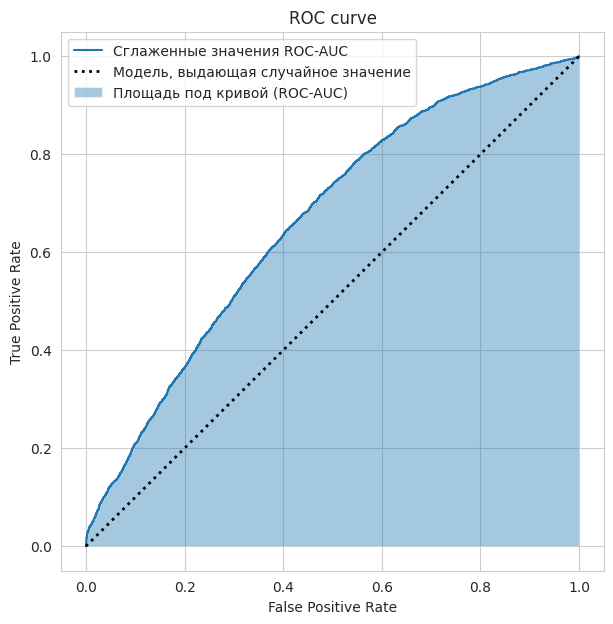

In [ ]:
# создаём график
plt.figure(figsize=(7, 7))

# рисуем кривую
plt.plot(false_positive_rates, true_positive_rates, label='Сглаженные значения ROC-AUC')

# кривая, соответствующая случайному угадыванию
plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle=':', label='Модель, выдающая случайное значение')

plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.fill_between(false_positive_rates, true_positive_rates, alpha=0.4, label='Площадь под кривой (ROC-AUC)')
plt.legend()
plt.show()

Чем ближе в целом кривая **ROC** к **левому верхнему** углу, тем лучше качество классификации.

Несмотря на наглядность, иногда требуется некоторое число, обобщающее весь
график. Для ROC кривой таким числом является "площадь под кривой" (**ROC-AUC**).

В **sklearn** есть специальная функция **roc_auc_score()** для подсчёта
площади под ROC-кривой.

In [ ]:
from sklearn.metrics import roc_auc_score

Типичная шкала для **ROC-AUC** (часто все зависит от задачи):
* $0.90$ - $1.00$ отлично;
* $0.80$ - $0.90$ хорошо;
* $0.70$ - $0.80$ удовлетворительно;
* $0.60$ - $0.70$ плохо;
* $0.50$ - $0.60$ очень плохо;
* $0.00$ - $0.50$ классификатор перепутал метки.

Вычислите значения *roc_auc_value* для обеих моделей

In [ ]:
# 24. TODO

test_probabilities = log_reg_model.predict_proba(test_points)[:, 1]
roc_auc_value = roc_auc_score(test_values, test_probabilities)

print("ROC-AUC на тестовой выборке для логистической регрессии:", roc_auc_value)

ROC-AUC на тестовой выборке для логистической регрессии: 0.6617972668406271


In [ ]:
# 25. TODO
test_probabilities = random_forest_model.predict_proba(test_points)[:, 1]
roc_auc_value = roc_auc_score(test_values, test_probabilities)

print("ROC-AUC на тестовой выборке для дерева решений:", roc_auc_value)

ROC-AUC на тестовой выборке для дерева решений: 0.8373501278972956


Выведите график ROC-AUC для алгоритма Random Forest. Попробуйте проанализировать параметры модели и добиться значения ROC-AUC ≥ 0.9

In [ ]:
# 26. TODO

false_positive_rates, true_positive_rates, threshold = roc_curve(test_values, test_probabilities)

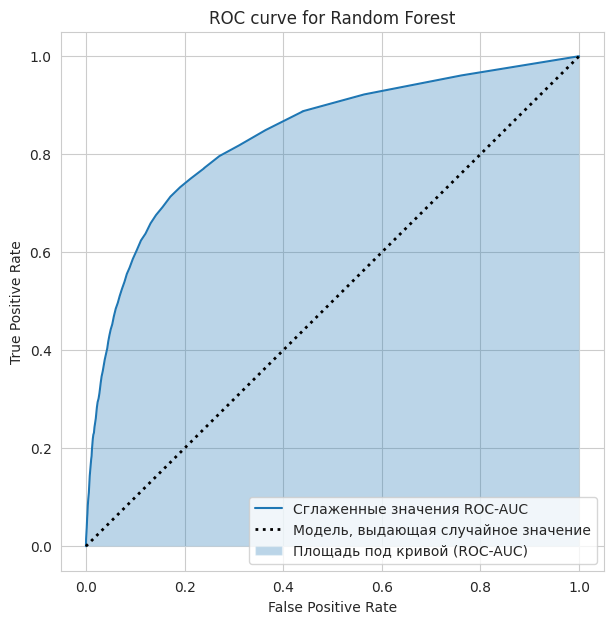

ROC-AUC на тестовой выборке для дерева решений: 0.8373501278972956


In [ ]:

# создаём график
plt.figure(figsize=(7, 7))

# рисуем кривую
plt.plot(false_positive_rates, true_positive_rates, label='Сглаженные значения ROC-AUC')

# кривая, соответствующая случайному угадыванию
plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle=':', label='Модель, выдающая случайное значение')

plt.title('ROC curve for Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.fill_between(false_positive_rates, true_positive_rates, alpha=0.3, label='Площадь под кривой (ROC-AUC)')
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC на тестовой выборке для дерева решений:", roc_auc_value)

ROC-AUC для дерева решений: **0.842**

Проанализируем параметры модели, не трогая имеющуюся обучающую выборку, чтобы повысить метрику.

**Основные параметры RandomForestClassifier из библиотеки sklearn**  
- `n_estimators` - количество деревьев в лесу, при увеличении повышает точность
- `class_weight` - веса классов. Значение 'balanced_subsample' позволяет модели лучше работать с несбалансированными данными (модель обращает больше внимания на менее представленный класс)
- `min_sample_leaf` - минимальное количество образцов в листовом узле. При увеличении позволяет не переобучаться модели на шуме
- `random_state` - фиксация случайной работы алгоритма
- `max_depth` - максимальная глубина дерева. Стандартное значение None (без ограничений)
- `max_features` - максимальное число признаков для разбиения. Стандартное значение sqrt (корень из количества признаков)

In [ ]:
better_rand_forest = ensemble.RandomForestClassifier(n_estimators=500, min_samples_leaf=50, class_weight='balanced_subsample')

In [ ]:
better_rand_forest.fit(training_points, training_values)

RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=50,
                       n_estimators=500)

In [ ]:
test_better_proba = better_rand_forest.predict_proba(test_points)[:, 1]

false_positive_rates, true_positive_rates, threshold = roc_curve(test_values, test_better_proba)
better_roc_auc_value = roc_auc_score(test_values, test_better_proba)

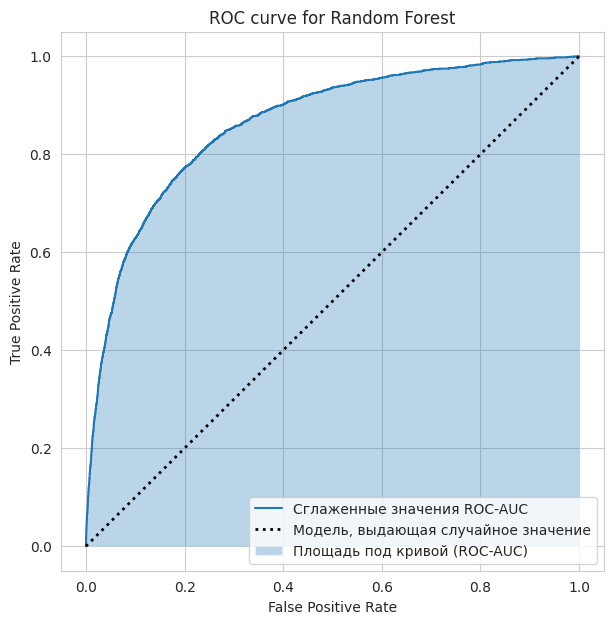

ROC-AUC на тестовой выборке для дерева решений: 0.8631898024425446


In [ ]:

# создаём график
plt.figure(figsize=(7, 7))

# рисуем кривую
plt.plot(false_positive_rates, true_positive_rates, label='Сглаженные значения ROC-AUC')

# кривая, соответствующая случайному угадыванию
plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle=':', label='Модель, выдающая случайное значение')

plt.title('ROC curve for Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.fill_between(false_positive_rates, true_positive_rates, alpha=0.3, label='Площадь под кривой (ROC-AUC)')
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC на тестовой выборке для дерева решений:", better_roc_auc_value)

После тестировани различных конфигураций параметров модели, была получена метрика ROC-AUC=**0.863**. Значение незначительно увеличилось, по сравнению с прошлой моделью.

Лучшее значение было получено при значениях параметров:  
`n_estimators` = 500  
`min_samples_leaf` = 50  
`class_weight` = 'balanced_subsample'  

При увеличении значений n_estimators и min_sample_leaf качество точность по ROC-AUC не увеличивалась, а время обучения модели росло. Иные параметры при изменении стандартных значений ROC-AUC не увеличивали.

Вероятно, для дальнейшего уввеличения качества модели, стоит произвести чистку данных, фич-инжиниринг, попробовать иные методы заполнения пустых значений.

# Самостоятельная работа


## Пункт 3.

> Исследуйте другие модели для реализации классификации значений. Постарайтесь построить более точную модель, модель, имеющую ошибку, меньшую чем в рассматриваемых в борде (например, SVM, kNN). При невозможности получить более точную модель, используйте LLM инструменты для того чтобы это сделать (альтернативно: опишите с помощью LLM, почему это сделать невозможно).


Далее будут рассмотрены следующие модели:
- SVM (метод опорных векторов)
- KNN (метод k-ближайших соседей)
- HistGradientBoosting
- Naive Bayes

Для удобства создадим функцию подсчёта метрики ROC-AUC и вывода графика. Также будем считать метрики precision (точность) и recall (полнота):

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
def roc_auc_func(test_model_values):
  false_positive_rates, true_positive_rates, threshold = roc_curve(test_values, test_model_values)
  roc_auc_value = roc_auc_score(test_values, test_model_values)

  bin_pred = (test_model_values >= 0.5).astype(int)
  precision = precision_score(test_values, bin_pred)
  recall = recall_score(test_values, bin_pred)
  f1 = f1_score(test_values, bin_pred)



  # создаём график
  plt.figure(figsize=(7, 7))

  # рисуем кривую
  plt.plot(false_positive_rates, true_positive_rates, label='Сглаженные значения ROC-AUC')

  # кривая, соответствующая случайному угадыванию
  plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle=':', label='Модель, выдающая случайное значение')

  plt.title('ROC curve')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')

  plt.fill_between(false_positive_rates, true_positive_rates, alpha=0.3, label='Площадь под кривой (ROC-AUC)')
  plt.legend(loc='lower right')
  plt.show()


  print("ROC-AUC на тестовой выборке", roc_auc_value)
  print("Precision на тестовой выборке", precision)
  print("Recall на тестовой выборке", recall)
  print("F1-score на тестовой выборке", f1)

Посчитаем значение для RandomForest

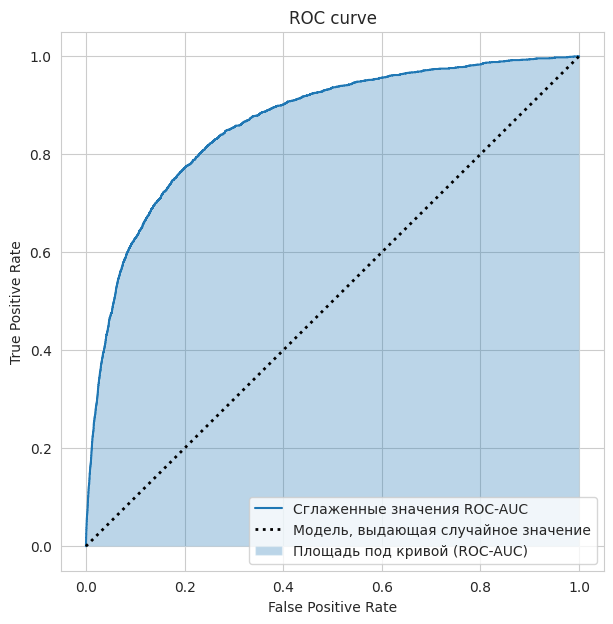

ROC-AUC на тестовой выборке 0.8631898024425446
Precision на тестовой выборке 0.24129839655846697
Recall на тестовой выборке 0.7324891175306688
F1-score на тестовой выборке 0.36301235536379683


In [ ]:
roc_auc_func(test_better_proba)

1. SVM - метод опорных векторов.
Суть алгоритма заключается в нахождении какой-то разделяющей плоскости (гиперплоскости), которая делит наши классы. Если прямую линию или плоскость между данными провести нельзя, то алгоритм повышает размерность пространства. Делается это с помощью ядер (kernels). Самым быстрым и подходящем в нашем случае является линейное ядро (linear)

In [ ]:
from sklearn.svm import SVC

In [ ]:
support_vector_alg = SVC(class_weight='balanced', probability=True, kernel='linear')

In [ ]:
# support_vector_alg.fit(training_points, training_values)

In [ ]:
# test_suppport_vector = support_vector_alg.predict_proba(test_points)[:, 1]
# roc_auc_func(test_support_vector)

Модель Support Vector Classifier (SVM/SVC) была включена в план исследования. Однако в ходе экспериментов выяснилось, что время обучения SVC на нашей выборке, объём которой более 50 000 объектов, составляет более 15 минут (в Google Collab) даже с линейным ядром, что в 10–15 раз дольше, чем у моделей на основе деревьев (Random Forest, использованный ранее).
Это связано с вычислительной сложностью алгоритма
O(n2)–O(n3) и дополнительными затратами на калибровку вероятностей (probability=True). Учитывая, что теоретически для задач кредитного скоринга критична важно скорость переобучения модели, чтобы постоянно улучшать качество одобрения кредитов, то в итоговое сравнение были включены более эффективные алгоритмы.

2. KNN - K-Nearest Neighbours
Суть метода заключается в поиске k максимально похожих соседей и принятие решения на основе них. В связи с этим время обучения модели крайне быстрое, а предсказание дольше, т.к. нам нужно посчитать расстояние до 50,000 обектов нашего датасета.

Так как в основе метода лежит подсчет расстояния между обектами, то возможна ситуация, когда, например, показатель дохода (нап. 50000) просто перекрывет показатель возраста (нап. 20), из-за чего в модели он не играет никакой роли. Для этого данные надо стандартизировать с помощью функции sklearn.preprocessing.StandardSkaler

Для удобства реализации и чтобы каждый раз не применять маштабирование данных, создадим Pipeline из той же библиотеки sklearn. Благодаря нему данные как для обучения так и для предсказания автоматически сначала будут проходить через StandardScaler, а потом уже через KNN.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_alg = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3, n_jobs=-1))
])

In [ ]:
knn_alg.fit(training_points, training_values)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='euclidean', n_jobs=-1,
                                      n_neighbors=3))])

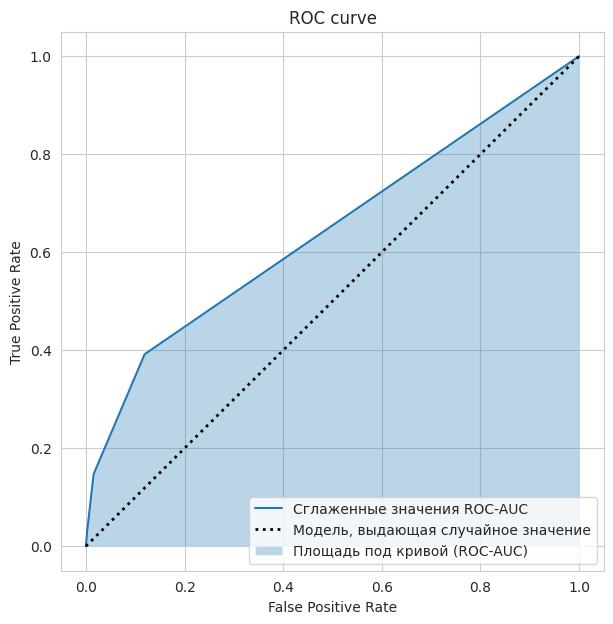

ROC-AUC на тестовой выборке 0.6421223230706177
Precision на тестовой выборке 0.4047878128400435
Recall на тестовой выборке 0.14721013058963198
F1-score на тестовой выборке 0.2159024956471271


In [ ]:
test_knn_alg = knn_alg.predict_proba(test_points)[:, 1]
roc_auc_func(test_knn_alg)

**Анализ полученных метрик**

Лучшая полученная конфигурация метрик указана выше. Единственный значимым улучшением оказалось уменьшение количества соседей, которые мы рассматриваем (5 -> 3)

На сырых данных данный метод однозначно неэффективен. Данные ROC-AUC около 0.65, что не сильно лучше случайного распределения. Значение точности 0.4, что плохо, но для кредитного скоринга важнее значение, полноты, которое находится на критически низком уровне.

3. HistGradientBoosting

Данный метод являетя по сути улучшенным методом RandomForest. Только в лесе решений у нас деревья строятся параллельно, а тут последовательно. Там у нас усередняется мнение нескольких деревьев, тут же каждое следующее дерево улучшает результат предыдущего. Гистограмным метод является, потому что перебирает не все значения признаков подряд, а корзинами (бинами), что повышает скорость обучения и практически не снижает точность.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [ ]:
grad_boosting_algo = ensemble.HistGradientBoostingClassifier(max_iter=500, min_samples_leaf=100, class_weight='balanced', early_stopping=True)

In [ ]:
grad_boosting_algo.fit(training_points, training_values)

HistGradientBoostingClassifier(class_weight='balanced', early_stopping=True,
                               max_iter=500, min_samples_leaf=100)

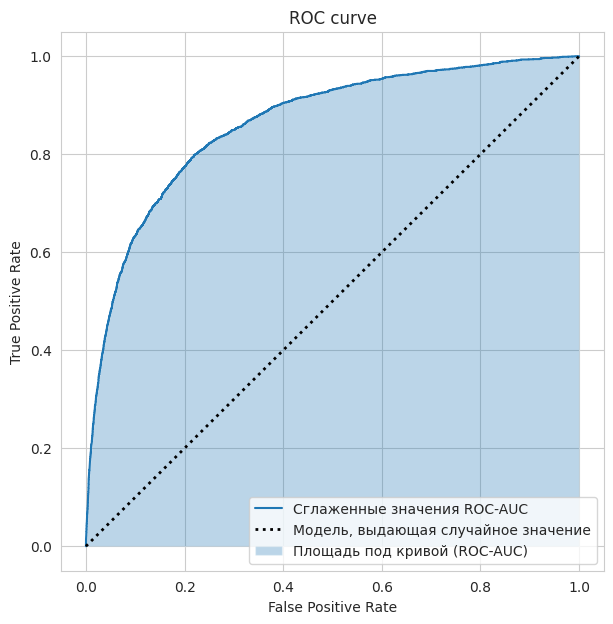

ROC-AUC на тестовой выборке 0.8628759586611282
Precision на тестовой выборке 0.2224520280363093
Recall на тестовой выборке 0.7661258409180847
F1-score на тестовой выборке 0.3447907390917186


In [ ]:
test_grad_boosting = grad_boosting_algo.predict_proba(test_points)[:, 1]
roc_auc_func(test_grad_boosting)

**Анализ полученных значений**

Использованные в модели параметры лишь незначительно меняют точность модели, если использовать параметры из модели RandomForest, то цифры будут примерно аналогичными

Так как метод по сути является лишь вариацией дерева решений, то. с точки зрения точности результат незначительно улучшился. Важное отличие здесь состоит в скорости обучения моделей. Когда классический лес обучался около 2 минут, метод градиентного спуска обучается практически мгновенно (по крайней мере на наших данных)

4. Naive Bayes

Это вероятностный алгоритм классификации, основанный на теореме Байеса с предположением о независимости признаков. Модель не строит сложные границы, а считает вероятность принадлежности к классу на основе значений признаков в обучающих данных

Так как большинство признаков непрерывные величины, то будем использовать GaussianNB

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
bayes_alg = GaussianNB()

In [ ]:
bayes_alg.fit(training_points, training_values)

GaussianNB()

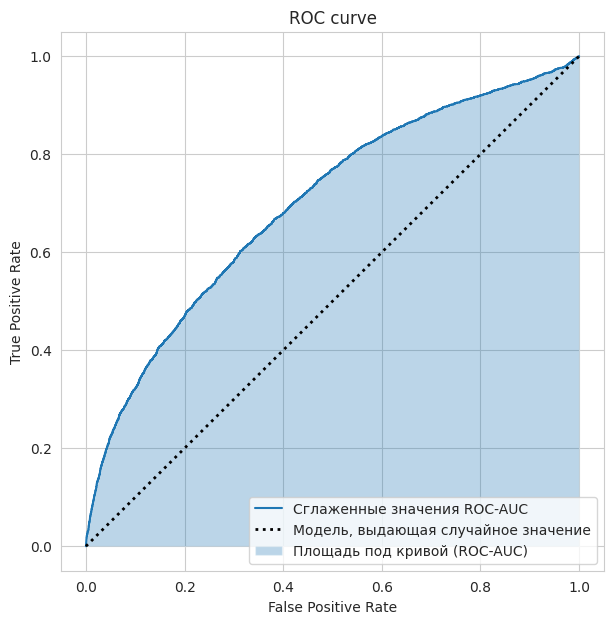

ROC-AUC на тестовой выборке 0.6971581197507204
Precision на тестовой выборке 0.4222222222222222
Recall на тестовой выборке 0.022556390977443608
F1-score на тестовой выборке 0.04282494365138993


In [ ]:
test_bayes_alg = bayes_alg.predict_proba(test_points)[:, 1]
roc_auc_func(test_bayes_alg)

**Анализ полученных значений**

Полученные значения метрик критично низкие для нашей задачи. Помимо низких значений Точности и ROC-AUC, главная наша метрика, полнота, получила значение 0.023. То есть, наша модель предсказывает лишь 2% людей, не заплативших за кредит.

### ВЫВОД

Таким образом, из рассмотренных моделей адекватные для нашей задачи значения были получены лишь с помощью моделей деревьев решений (RandomForest, HistGradientBoosting). Остальные модели либо выдавали критически низкие метрики для нашей бизнесс задачи, либо были непригодны для обучения из-за своей сложности.

Можно выделить несколько причин невозможности повышения точности модели

1. С данными была проведена базовая работа, не было не фич-инжиниринга, ни обработки выбросов
2. Не было никакой работы с дисбалансом классов (помимо указания соответствующих параметоров функций)
3. Малое количество признаков. Возможно для данной проблемы, чтобы получить более точно предсказание, следует знать больше информации о клиенте

# Пункт 4 и 5.
> Изучите какие алгоритмы классификации используются сейчас, проанализировав научные публикации по теме и/или соответствующие исследования в kaggle (например, вот такое).  


На данный момент наивысшая точность и значение ROC-AUC в профессиональной среде достигается благодаря не более сложным моделям, а более качественной работе с данными. Сюда входит первичная обработка, обработка выборосов и пустых значений, работа с признаками, фич-инжиниринг, работа с дисбалансом, аугментация данных и т.д. Самыми популярными моделями классификации (по крайней мере на соревнованиях и хакатонах kaggle) являются методы ансамблей на основе градиентного бустинга и деревьев решений (XGBoost, CatBoost), которые раннее были рассмотрены на базовом уровне. Проблема более сложных моделей заключается не только в более сложной настройке или времени обучения, а так же со сложностью интерпретируемости (что крайне важно для бизнеса). Также, конечно, есть и различные нейросетевые значения. Но по соотношению точность/затраты для обычных табличных данных они проигрывают вышеуказанным методам.

> Исследуйте (опционально с помощью LLM) каким образом обученную модель можно интегрировать с веб-сервисом, реализованным с помощью веб-фреймворка Flask / Django / FastAPI и опишите тезисно пошаговый алгоритм, что необходимо для этого сделать.

Процесс интеграции модели с веб-сервисом

1. Для начала модель вместе со всеми предобработками сохранаяется в бинарный файл (нап. `joblib.dump(model, 'model.pkl')`), так же надо сохранить версии библиотек в файла reauirments.txt
2. Модель надо загрузит в каталог проекта, указать её в gitignore (`*.pkl`), саму модель в репозиторий коммитить не стоит, лучше её расположить в облаке и подключать при деплое
3. Получаем POST запрос с json в теле запроса, обрабатываем, возвращаем результат + код
Пример:
```python
data = request.get_json()           # Получить JSON
df = pd.DataFrame([data])           # Преобразовать в DataFrame
pred = model.predict(df)[0]         # Предсказание
proba = model.predict_proba(df)[0]  # Вероятности
return jsonify({'prediction': pred, 'probability': proba})
```
4. Далее остается только поддерживать модель, следить за её актуальностью и работоспособностью